In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Osnovne informacije o cjelokupnom skupu podataka

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MU projekat/creditscore_dataset.csv')

<ipython-input-27-7acd655e84c9>:1: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/MU projekat/creditscore_dataset.csv')


Dimenzije skupa podataka

In [ ]:
print(f"Broj redova (primjera): {df.shape[0]}")
print(f"Broj kolona (varijabli): {df.shape[1]}")

Broj redova (primjera): 100022
Broj kolona (varijabli): 30


Namjena varijabli

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100022 entries, 0 to 100021
Data columns (total 30 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0.2              100022 non-null  int64  
 1   Unnamed: 0                100022 non-null  int64  
 2   Unnamed: 0.1              100022 non-null  int64  
 3   ID                        100022 non-null  object 
 4   Customer_ID               100022 non-null  object 
 5   Month                     100022 non-null  object 
 6   Name_and_Age              90034 non-null   object 
 7   SSN                       100022 non-null  object 
 8   Occupation                100022 non-null  object 
 9   Annual_Income             100022 non-null  object 
 10  Monthly_Inhand_Salary     85013 non-null   float64
 11  Num_Bank_Accounts         100022 non-null  object 
 12  Num_Credit_Card           100022 non-null  object 
 13  Interest_Rate             100022 non-null  i

# Analiza pojedinačnih kolona

In [ ]:
columns = ['ID', 'Customer_ID', 'Month', 'Name_and_Age', 'SSN', 'Occupation']
columns_data = df[columns]

# deskriptivna statistika za kolone
columns_data.describe(include='all')

,ID,Customer_ID,Month,Name_and_Age,SSN,Occupation
count,100022,100022,100022,90034,100022,100022
unique,100000,12500,8,25520,12501,46
top,0x14c33,CUS_0x5313,April,"Stempelj,35",#F%$D@*&8,_______
freq,2,9,12505,16,5576,7063




*   **ID** - identifikator za slogove u bazi podataka, numerička varijabla (npr. 1234)
*   **Customer_ID** - identifikator kupca, tipa string (npr. CUS_0xd00)
*   **Month** - kategorička varijabla za mjesec u godini (npr. May)
*   **Name_and_Age** - kombinacija imena i godina osobe razdvojeno zarezom (npr. John Doe, 25)
*   **SSN** - Social Security Number (npr. 000-11-2222)
*   **Occupation** - Zanimanje (npr. Scientist)







In [ ]:
#tipovi varijabli

columns_data.dtypes

,0
ID,object
Customer_ID,object
Month,object
Name_and_Age,object
SSN,object
Occupation,object


# Analiza i vizualizacija prije čišćenja

## ID kolona

Varijabla ID služi kao jedinstveni identifikator, što znači da je nije korisno analizirati ili vizualizirati jer nema analitičke vrijednosti.
Provjerit ćemo broj jedinstvenih vrijednosti u koloni.

In [ ]:
unique_ids = df['ID'].nunique()
print(unique_ids)

100000


## Customer_ID kolona

Slično kao i za prethodnu kolonu, Customer_ID predstavlja identifikator. Provjerit ćemo broj jedinstvenih kupaca. Zatim ćemo vizualizirati aktivnost kupaca.

In [ ]:
unique_customers = df['Customer_ID'].nunique()
print(unique_customers)

12500


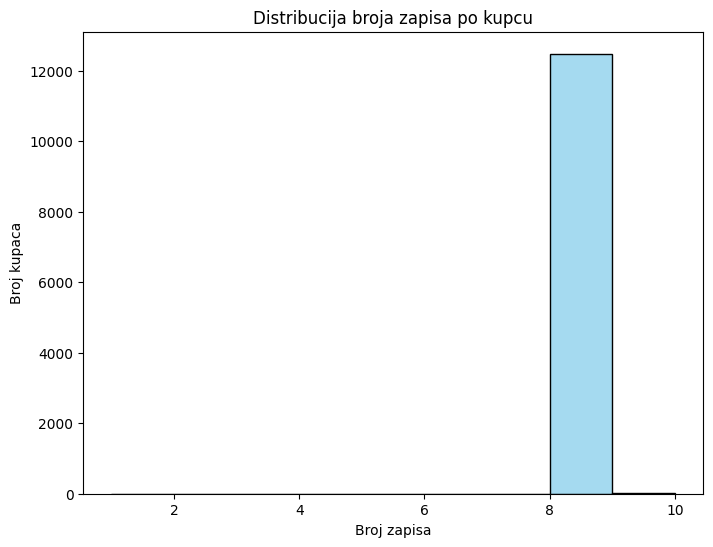

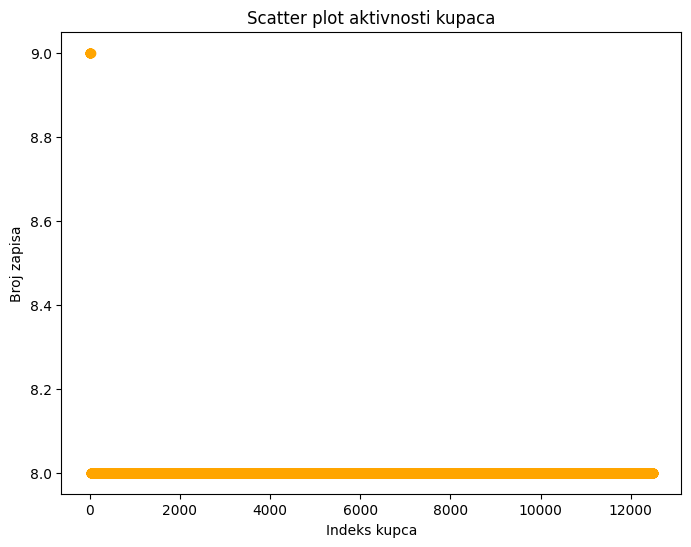

In [ ]:
customer_activity = df['Customer_ID'].value_counts()

# Histogram za distribuciju broja zapisa po kupcu
plt.figure(figsize=(8, 6))
sns.histplot(customer_activity, bins=range(1, customer_activity.max() + 2), kde=False, color="skyblue")
plt.title("Distribucija broja zapisa po kupcu")
plt.xlabel("Broj zapisa")
plt.ylabel("Broj kupaca")
plt.show()

# Scatter plot za prikaz aktivnosti kupaca
plt.figure(figsize=(8, 6))
plt.scatter(range(len(customer_activity)), customer_activity, color='orange')
plt.title("Scatter plot aktivnosti kupaca")
plt.xlabel("Indeks kupca")
plt.ylabel("Broj zapisa")
plt.show()

## Months kolona


Distribucija vrijednosti za 'Month':
Month
April       12505
8           12504
January     12503
6           12503
3           12502
May         12502
July        12502
February    12501
Name: count, dtype: int64


<ipython-input-10-cc6a381e589a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=df, palette='viridis')


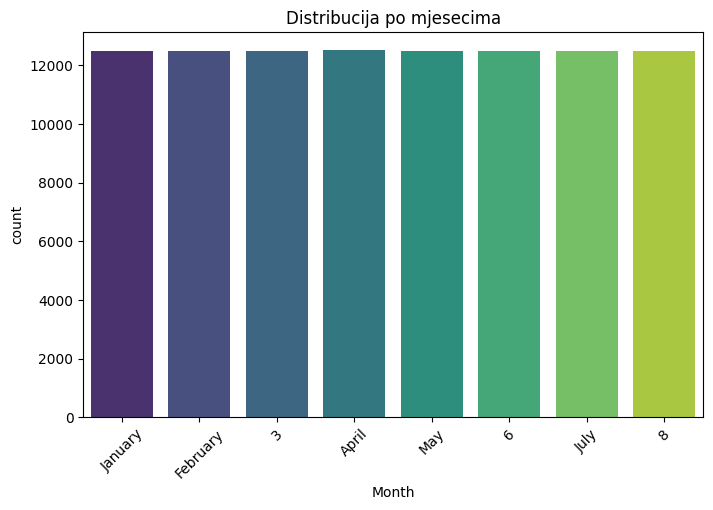

In [ ]:
print("\nDistribucija vrijednosti za 'Month':")
print(df['Month'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='Month', data=df, palette='viridis')
plt.title("Distribucija po mjesecima")
plt.xticks(rotation=45)
plt.show()

## Name_and_Age kolona

Mean: 117.41965376211553
Trim Mean (10%): nan
Median: 33.0
Min: 14.0
Max: 8698.0
Standardna devijacija: 692.6141313114764
Varijansa: 479714.334892351
Rang: 8684.0


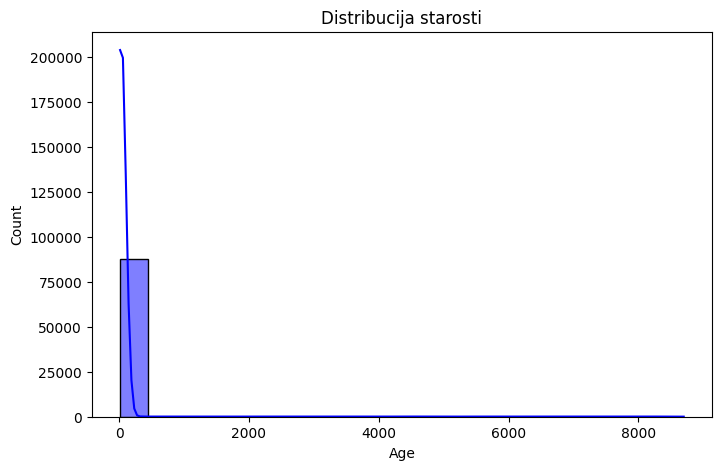

In [ ]:
from scipy.stats import trim_mean

df[['Name', 'Age']] = df['Name_and_Age'].str.extract(r'([a-zA-Z\s]+),\s*(\d+)')
df['Age'] = pd.to_numeric(df['Age'])

age = df['Age']
mean = age.mean()
trimmed_mean = trim_mean(age, 0.1)
median = age.median()
minimum = age.min()
maximum = age.max()
std_dev = age.std()
variance = age.var()
data_range = maximum - minimum

print(f"Mean: {mean}")
print(f"Trim Mean (10%): {trimmed_mean}")
print(f"Median: {median}")
print(f"Min: {minimum}")
print(f"Max: {maximum}")
print(f"Standardna devijacija: {std_dev}")
print(f"Varijansa: {variance}")
print(f"Rang: {data_range}")


plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, bins=20, color='blue')
plt.title("Distribucija starosti")
plt.show()

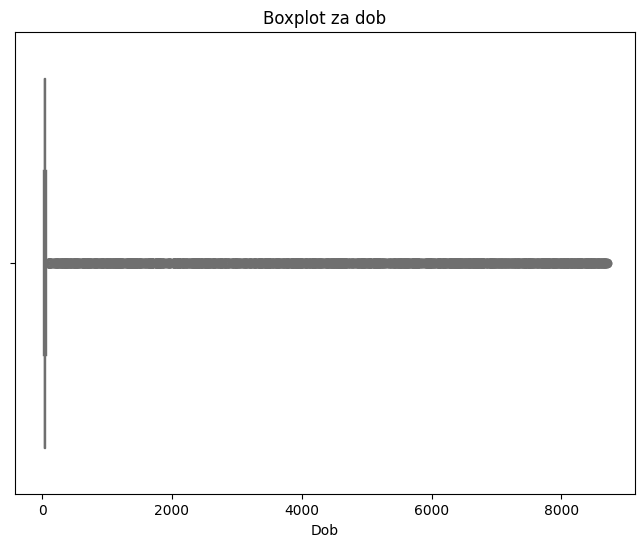

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Age'], color='skyblue')
plt.title('Boxplot za dob')
plt.xlabel('Dob')
plt.show()

In [ ]:
from google.colab import files

# Spremite DataFrame u CSV datoteku
df.to_csv('dataset.csv', index=False)

# Preuzmite datoteku
files.download('dataset.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## SSN

SSN (Social Security Number) također predstavlja određenu vrstu identifikatora te nema analitičku vrijednost pa nećemo prikazivati vizualizaciju ove kolone.

In [ ]:
print("\nProvjera jedinstvenosti SSN:")
print(df['SSN'].nunique(), "jedinstvenih vrijednosti od", len(df))

print("Broj nedostajućih vrijednosti: ", df['SSN'].isnull().sum())



Provjera jedinstvenosti SSN:
12501 jedinstvenih vrijednosti od 100022
Broj nedostajućih vrijednosti:  0


## Occupation

Broj nedostajućih vrijednosti Occupation 0

Distribucija za 'Occupation':
Occupation
_______          7063
Lawyer           6325
Architect        6126
Engineer         6126
Mechanic         6076
Scientist        6074
Accountant       6033
Teacher          6004
Developer        5982
Media_Manager    5982
Entrepreneur     5933
Journalist       5868
Doctor           5858
Manager          5740
Musician         5685
Writer           5648
DEVELOPER         142
media_manager     141
DOCTOR            138
ENTREPRENEUR      131
LAWYER            129
WRITER            126
ARCHITECT         125
accountant        123
lawyer            123
ENGINEER          121
manager           120
MUSICIAN          120
SCIENTIST         118
MANAGER           116
ACCOUNTANT        116
JOURNALIST        115
mechanic          114
entrepreneur      113
developer         112
teacher           111
writer            111
MEDIA_MANAGER     110
scientist         108
musician          108
engineer          105
journalist   

<ipython-input-63-49d016340d88>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Occupation', data=df, palette='cool')


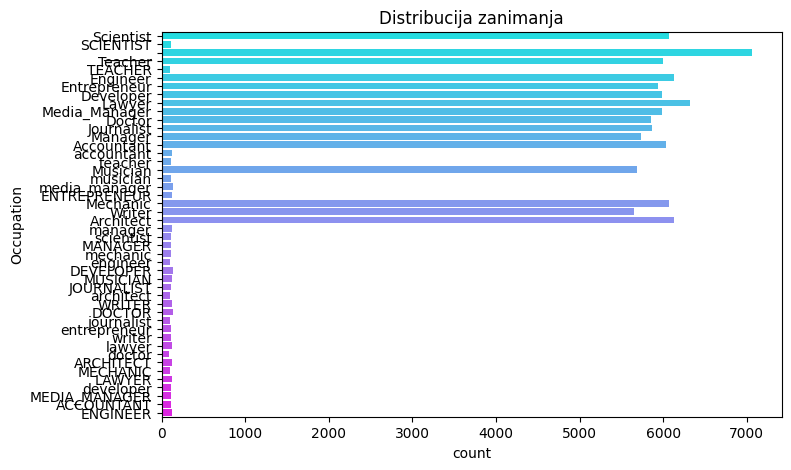

In [ ]:
print("Broj nedostajućih vrijednosti Occupation", df['Occupation'].isnull().sum())

print("\nDistribucija za 'Occupation':")
print(df['Occupation'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(y='Occupation', data=df, palette='cool')
plt.title("Distribucija zanimanja")
plt.show()

# Čišćenje

U prvom koraku ćemo ukloniti kolone 'Unnamed: 0', 'Unnamed: 0.1', i 'Unnamed: 0.2', jer nam one ne daju nikakvu informaciju i napravile bi problem prilikom treniranja modela.

In [ ]:
print("Kolone u datasetu prije uklanjanja:")
print(df.columns)

df = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.2'], errors='ignore')

print("\nKolone u datasetu nakon uklanjanja:")
print(df.columns)


Kolone u datasetu prije uklanjanja:
Index(['Unnamed: 0.2', 'Unnamed: 0', 'Unnamed: 0.1', 'ID', 'Customer_ID',
       'Month', 'Name_and_Age', 'SSN', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'Name', 'Age'],
      dtype='object')

Kolone u datasetu nakon uklanjanja:
Index(['ID', 'Customer_ID', 'Month', 'Name_and_Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_

Zatim ćemo ukloniti i kolone 'ID' i 'Customer_ID' iz razloga što one predstavljaju identifikatore, odnosno primarni i strani ključ u bazi podataka te nam kao takve nisu potrebne u treniranju modela, odnosno njihovim uključivanjem u trening skup bismo otežali našem modelu da uči iz ovih podataka.

In [ ]:
df = df.drop(columns=['ID'], errors='ignore')

print("\nKolone u datasetu nakon uklanjanja:")
print(df.columns)


Kolone u datasetu nakon uklanjanja:
Index(['Month', 'Name_and_Age', 'SSN', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'Name', 'Age'],
      dtype='object')


U koloni 'Month' neki su mjeseci prikazani imenom, a neki brojem. Mi ćemo prečistiti ovu kolonu tako da je mjesec u svakom slogu prikazan imenom.

In [ ]:
import calendar

def convert_month(value):
    try:
        if isinstance(value, int) or value.isdigit():
            return calendar.month_name[int(value)]
        elif value.capitalize() in calendar.month_name:
            return value.capitalize()
    except ValueError:
        return value

df['Month'] = df['Month'].apply(convert_month)
print(df['Month'].unique())

df['Month'] = pd.Categorical(df['Month'], categories=calendar.month_name[1:], ordered=True)
df = df.sort_values(by='Month')


['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August']


Provjera za nedostajuće vrijednosti

In [ ]:
missing_values_count = df['Month'].isnull().sum()

if missing_values_count > 0:
    print(f"U koloni 'Month' postoji {missing_values_count} nedostajućih vrijednosti.")
else:
    print("Nema nedostajućih vrijednosti u koloni 'Month'.")


Nema nedostajućih vrijednosti u koloni 'Month'.


Sljedeći kod broji koliko slogova nema postavljenu vrijednost 'Name_and_Age' kolone

In [ ]:
missing_count = df['Name_and_Age'].isnull().sum() + (df['Name_and_Age'].str.strip() == '').sum()

print(f"Broj slogova bez postavljene vrijednosti u koloni 'Name_and_Age': {missing_count}")


Broj slogova bez postavljene vrijednosti u koloni 'Name_and_Age': 9988


S obzirom na to da veliki broj podataka nema postavljenu vrijednost
Name_and_Age kolone (blizu 10%), nećemo brisati ove slogove zbog gubljenja podataka pa ćemo iz postaviti na globalnu konstantu 'Unknown, 0'

In [ ]:
df['Name_and_Age'] = df['Name_and_Age'].fillna('Unknown,0')

print(df['Name_and_Age'].head())

missing_count = df['Name_and_Age'].isnull().sum() + (df['Name_and_Age'].str.strip() == '').sum()

print(f"Broj slogova bez postavljene vrijednosti u koloni 'Name_and_Age': {missing_count}")



0      Aaron Maashoh,23
1      Aaron Maashoh,23
2    Aaron Maashoh,-500
3      Aaron Maashoh,23
4      Aaron Maashoh,23
Name: Name_and_Age, dtype: object
Broj slogova bez postavljene vrijednosti u koloni 'Name_and_Age': 0


Uklanjamo karaktere s početka koji nisu slova

In [ ]:
import regex as re

def remove_non_alpha_start(text):
    return re.sub('^[^a-zA-Z]+', '', text)

df['Name_and_Age'] = df['Name_and_Age'].apply(remove_non_alpha_start)

Pretvaramo početno slovo svakog imena u veliko

In [ ]:
df['Name_and_Age'] = df['Name_and_Age'].apply(lambda x: x.capitalize())


Provjeravamo koliko slogova u ovom trenutku ima ispravan format

In [ ]:
regex = r'^[A-Za-z]+,.*$'

matching_rows = df['Name_and_Age'].str.match(regex).sum()

print(f'Broj slogova koji odgovaraju regexu: {matching_rows}')


Broj slogova koji odgovaraju regexu: 63125


Provjeravamo postoje li slogovi koji nemaju zarez, jer želimo razdvojiti Name i Age po zarezu

In [ ]:
regex_no_comma = r'^[^,]*$'

no_comma_rows = df['Name_and_Age'].str.match(regex_no_comma).sum()

print(f'Broj slogova koji nemaju zarez: {no_comma_rows}')

Broj slogova koji nemaju zarez: 0


S obzirom na to da nema slogova bez zareza, provjeravamo ima li slogova sa više od jednim zarezom, jer i to bi stvorilo problem pri razdvajanju slogova

In [ ]:
count_more_than_one_comma = df['Name_and_Age'].str.count(',') > 1

num_rows_with_multiple_commas = count_more_than_one_comma.sum()

rows_with_multiple_commas = df[df['Name_and_Age'].str.count(',') > 1]

print(f'Broj slogova s više od jednog zareza: {num_rows_with_multiple_commas}')
print(rows_with_multiple_commas[['Name_and_Age']])


Broj slogova s više od jednog zareza: 7
               Name_and_Age
22886  Jeremy wagstaff,n,23
22887  Jeremy wagstaff,n,23
22888  Jeremy wagstaff,n,23
22889  Jeremy wagstaff,n,23
22890  Jeremy wagstaff,n,23
22892  Jeremy wagstaff,n,23
22893  Jeremy wagstaff,n,23


Imamo 7 slogova sa više od jednog zareza što je mali procenat u našem dataset-u pa možemo obrisati ove slogove radi jednostavnosti

In [ ]:
df = df[df['Name_and_Age'].str.count(',') <= 1]

Sada razdvajamo Name_and_Age kolonu na Name i Age

In [ ]:
df[['Name', 'Age']] = df['Name_and_Age'].str.split(',', expand=True)

Brišemo kolonu Name_and_Age

In [ ]:
df = df.drop('Name_and_Age', axis=1)

Kolonu 'Age' pretvaramo u numerički tip. Trenutno je tipa object jer se u njoj nalaze podaci gdje se pored godina nalaze i neki dodatni karakteri koje je potrebno ukloniti.
Zatim iz godina brišemo nenumeričke karaktere te postavljamo besmislene vrijednosti godina na globalnu konstantu 0.

In [ ]:
import regex as re

def remove_non_numerical(text):
    return re.sub('[^0-9]+', '', text)

df['Age'] = df['Age'].apply(remove_non_numerical)

In [ ]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [ ]:
df.loc[df['Age'] > 100, 'Age'] = 0

In [ ]:
num_rows_with_age_0 = df[df['Age'] == 0].shape[0]

print(f'Broj slogova gdje je Age = 0: {num_rows_with_age_0}')


Broj slogova gdje je Age = 0: 12496


In [ ]:
#računamo median za slogove različite od 0
median_age = df.loc[df['Age'] != 0, 'Age'].median()

# Zamjena vrijednosti 0 s medijanom
df['Age'] = df['Age'].replace(0, median_age)

Neispravne vrijednosti SSN-a postavljamo na Unknown, s obzirom na to da SSN vjerovatno niti neće biti korišten prilikom treniranja modela

In [ ]:
def replace_invalid_SSN(text):
    if not re.match(r'^\d{3}-\d{2}-\d{4}$', text):
        return 'Unknown'
    return text

df['SSN'] = df['SSN'].apply(replace_invalid_SSN)


U koloni Occupation treba nazive zanimanja prebaciti u isti format, jer imamo ista zanimanja pod dva naziva, negdje malim a negdje velikim slovima

In [ ]:
df['Occupation'] = df['Occupation'].str.lower()

In [ ]:
from google.colab import files
df.to_csv('precisceni.csv', index=False)
files.download('precisceni.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Analiza i vizualizacija poslije čišćenja

## Name

<ipython-input-27-31ea5bc26669>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_names.values, y=top_names.index, palette='viridis')


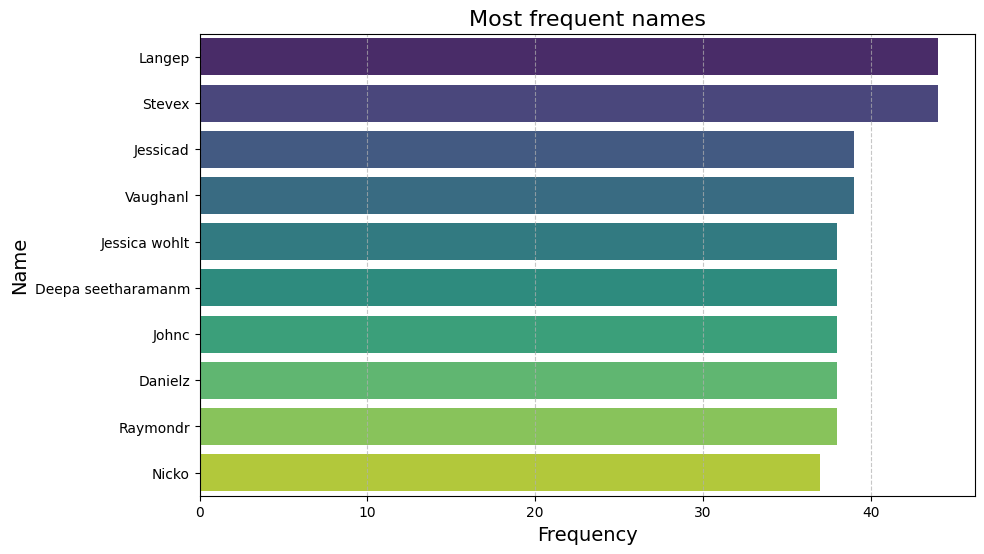

In [ ]:
filtered_names = df[df['Name'] != 'Unknown']

top_names = filtered_names['Name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_names.values, y=top_names.index, palette='viridis')
plt.title('Most frequent names', fontsize=16)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Name', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## Age

In [ ]:
age = df['Age']
mean = age.mean()
trimmed_mean = trim_mean(age, 0.1)
median = age.median()
minimum = age.min()
maximum = age.max()
std_dev = age.std()
variance = age.var()
data_range = maximum - minimum

print(f"Mean: {mean}")
print(f"Trim Mean (10%): {trimmed_mean}")
print(f"Median: {median}")
print(f"Min: {minimum}")
print(f"Max: {maximum}")
print(f"Standardna devijacija: {std_dev}")
print(f"Varijansa: {variance}")
print(f"Rang: {data_range}")



Mean: 33.27928810678398
Trim Mean (10%): 33.01560996338095
Median: 33.0
Min: 14
Max: 100
Standardna devijacija: 10.08120866491785
Varijansa: 101.63076814561474
Rang: 86


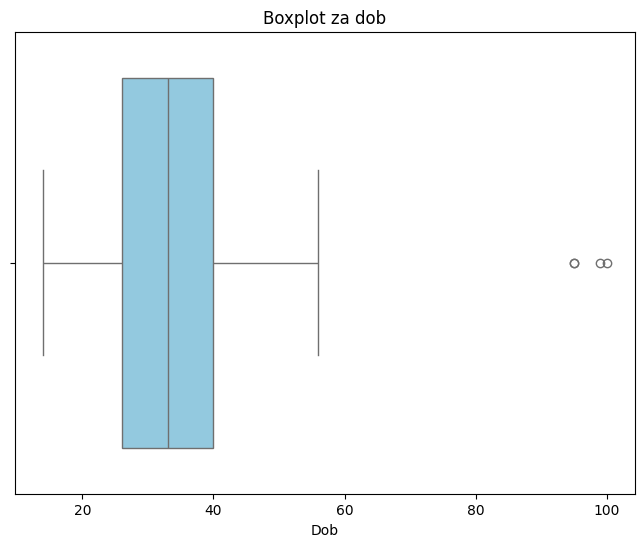

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Age'], color='skyblue')
plt.title('Boxplot za dob')
plt.xlabel('Dob')
plt.show()

# Boxplot za dob prema zanimanju (Occupation)
#plt.figure(figsize=(8, 6))
#sns.boxplot(x='Occupation', y='Age', data=df, palette='viridis')
#plt.title('Boxplot za dob prema zanimanju')
#plt.xlabel('Zanimanje')
#plt.ylabel('Dob')
#plt.xticks(rotation=45)
#plt.show()

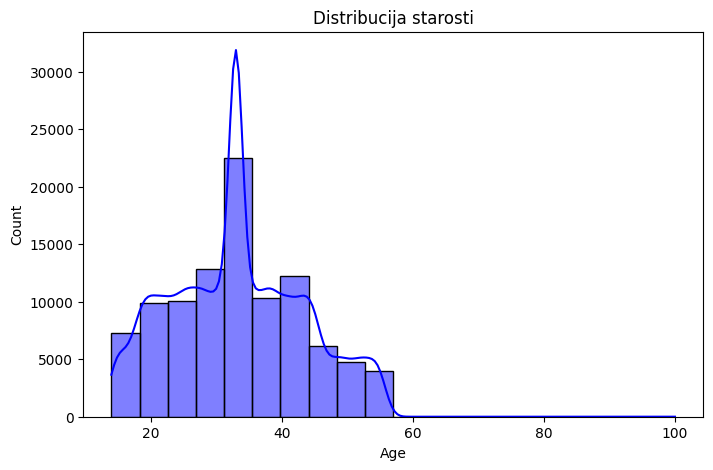

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, bins=20, color='blue')
plt.title("Distribucija starosti")
plt.show()

## Month


Distribucija vrijednosti za 'Month':
Month
April        12504
June         12503
August       12503
January      12502
March        12501
May          12501
July         12501
February     12500
September        0
October          0
November         0
December         0
Name: count, dtype: int64


<ipython-input-115-cc6a381e589a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Month', data=df, palette='viridis')


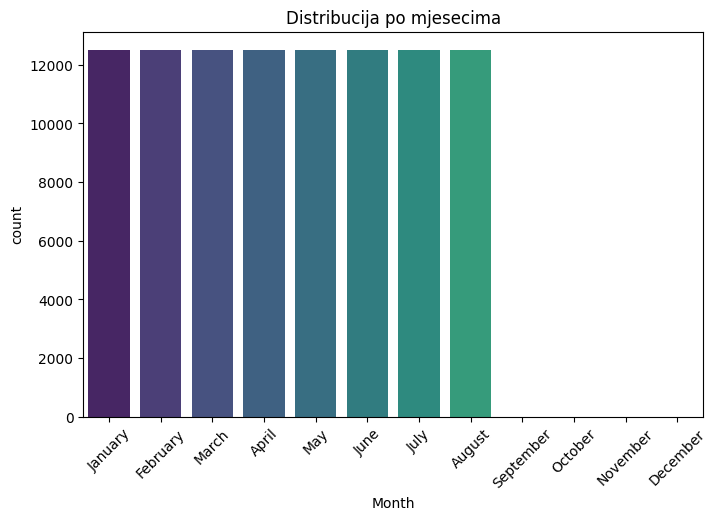

In [ ]:
print("\nDistribucija vrijednosti za 'Month':")
print(df['Month'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='Month', data=df, palette='viridis')
plt.title("Distribucija po mjesecima")
plt.xticks(rotation=45)
plt.show()

## Occupation


Distribucija za 'Occupation':
Occupation
lawyer           6577
architect        6355
engineer         6352
scientist        6300
mechanic         6292
accountant       6272
developer        6236
media_manager    6233
teacher          6215
entrepreneur     6177
doctor           6089
journalist       6087
manager          5976
musician         5913
writer           5885
Name: count, dtype: int64


<ipython-input-21-a110eae2ad13>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Occupation', data=df, palette='cool')


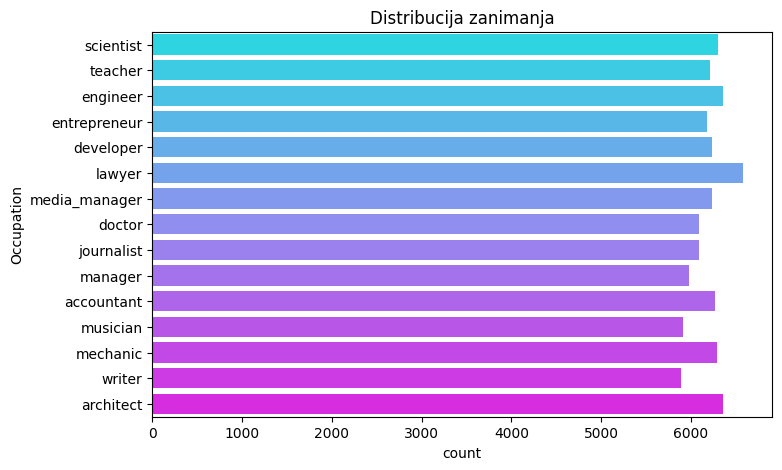

In [ ]:
#nedostajuće vrijednosti su unesene u dataset kao _______ pa ih mijenjamo sa nan
df['Occupation'] = df['Occupation'].replace('_______', np.nan)

print("\nDistribucija za 'Occupation':")
print(df['Occupation'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(y='Occupation', data=df, palette='cool')
plt.title("Distribucija zanimanja")
plt.show()

In [ ]:
print("Mode za Occupation atribut: ", df['Occupation'].mode())

Mode za Occupation atribut:  0    lawyer
Name: Occupation, dtype: object
